# PT3S
Use SIR 3S Modeldata and SIR 3S Results in pure Python.

With pandas, matplotlib and others.

For documentation, test, verification, analysis, reporting, prototyping, play.

## Install
Python 3.5.2 (Anaconda 4.2.0 (64-bit))

In [ ]:
!pip uninstall --yes PT3S
!pip install PT3S

## PT3S Imports

In [ ]:
%pwd

In [1]:
# currentWorkingDirectory should be after Kernel (Re-)Start the notebookDir 
# in this case PT3SSourcecodeDir (the Dir with PT3S' __init__.py and PT3S.ipynb (this notebook))

# PT3S-Imports:
# only if
# !pip install -e .
# is active 
# then _before the PT3S Imports the currentWorkingDirectory _has to be changed to .. PT3SSourcecodeDir  
%cd -q ..
from PT3S import Mx,Xm,Rm
%cd -q PT3S 
# if !pip install -e . is active the cd-Change has no effect  

# Imports

In [ ]:
import unittest
import doctest

# Test Mx

In [ ]:
# run the tests ...
unittest.TextTestRunner().run(doctest.DocTestSuite(Mx))  

# Test Xm

In [ ]:
# run the tests ...
unittest.TextTestRunner().run(doctest.DocTestSuite(Xm))  

# Test Rm

In [ ]:
# run the tests ...
unittest.TextTestRunner().run(doctest.DocTestSuite(Rm))  

In [2]:
# ---
# Imports
# ---
import logging
logger = logging.getLogger('PT3S')  
import os
import pandas as pd
import matplotlib.pyplot as plt
path = os.path.dirname('.')



# ---
# LocalHeatingNetwork
# ---
xmlFile=os.path.join(path,'testdata\LocalHeatingNetwork.XML')
xm=Xm.Xm(xmlFile=xmlFile)
type(xm)
#xm.dataFrames['vROHR']
mx1File=os.path.join(path,'testdata\WDLocalHeatingNetwork\B1\V0\BZ1\M-1-0-1.MX1')
mx=Mx.Mx(mx1File=mx1File,NoH5Read=True,NoMxsRead=True)
mx.setResultsToMxsFile(NewH5Vec=True)
type(mx)
rm=Rm.Rm(xm=xm,mx=mx)
#mx.df


In [3]:
plt.close('all')
fig=plt.figure() # black
#timeDeltaToT=mx.df.index[1]-mx.df.index[0]
#print(timeDeltaToT)


In [4]:
x=rm.pltNetDHUS(timeDeltaToT= pd.to_timedelta('15 seconds')   #timeDeltaToT
              #  ,quantil_pROHRAttributeLow=0.
                
 
                
                ,pFWVBMeasureInRefPerc=True # Measure wird verarbeitet in Prozent T zu Ref 
                ,pFWVBMeasure3Classes=False # Measure wird dargestellt in 3 Klassen   
                
                ,pFWVBAttribute='W0LFK'
                ,pFWVBrefSize=100
                
                # Label
                #,pMeasureUNIT=pFWVBMeasureUNIT
                #,pMeasureTYPE=pFWVBMeasureATTRTYPE

                # Ticks (TickLabels und TickValues)
                ,CBFixedLimits=False#CBFixedLimits
                #,CBFixedLimitLow=CBFixedLimitLow
                #,CBFixedLimitHigh=CBFixedLimitHigh        
             
                #,CBLabelPad=CBLabelPad # Label unmittelbar rechts neben der Colorbar
               
              #  ,CBAspect=CBAspect # ratio of long to short dimension
               # ,CBShrink=1.  
                #,CBAnchorVertical=0.                 
                
               )

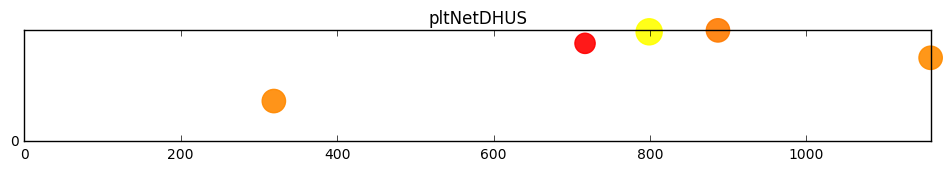

In [5]:
plt.show()

# Deploy

python setup.py clean sdist bdist_wheel 

pip install twine

twine upload dist/*

# Develop

In [ ]:
!pip install -e .

due to ...\Lib\site-packages\PT3S.egg-link

import PT3S 

will work (if PythonShell is executed .. PT3SSourcecodeDir)

and point to _local PT3SSourcecodeDir

Repository: https://github.com/aw3s/PT3S.git